In [25]:
import sys
from pathlib import Path

In [26]:
# Add the path to the utils folder to sys.path

utils_path = Path('/hpc/home/a1/WildfireProject/uavsar-main/python').resolve()
sys.path.append(str(utils_path))


In [27]:
import rasterio
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from process_utils import (preprocess_data,
                           superpixel_segmentation,
                            tv_denoise, 
                            preprocess_for_merge)
from rio_utils import (reproject_arr_to_match_profile)

In [28]:
# Opens a GeoTIFF and loads the backscatter values and profile
def open_one(path):
    with rasterio.open(path) as ds:
        band = ds.read(1)
        profile = ds.profile
    return band, profile

In [29]:
def inc_filter(img):
    img_deg = np.rad2deg(img)
    mask = (img_deg < 20) | (img_deg > 60)
    img_deg[mask] = 999
    return img_deg

In [30]:
def denoise(data, weight):
   mask = np.isnan(data)
   data[mask] = 9999
   data_tv = tv_denoise(data, weight)
   data_tv[mask] = np.nan

   return data_tv

In [31]:
def weighted_inc_merge(img_0, img_1, inc_0, inc_1):
    # Validate pixel values (ensuring they are within the valid range for both images and incidence angles)
    valid_pixel_0 = ~np.isnan(img_0) & (inc_0 >= 25) & (inc_0 <= 65)
    valid_pixel_1 = ~np.isnan(img_1) & (inc_1 >= 25) & (inc_1 <= 65)

    # Invalid pixel logic for handling missing or invalid data
    invalid_pixel_0 = np.isnan(img_0) | (inc_0 < 25) | (inc_0 > 65)
    invalid_pixel_1 = np.isnan(img_1) | (inc_1 < 25) | (inc_1 > 65)

    # Weight calculation (ensuring proper weighting per valid pixel)
    total_inc = inc_0 + inc_1
    w0 = np.where(total_inc > 0, inc_0 / total_inc, 0)
    w1 = np.where(total_inc > 0, inc_1 / total_inc, 0)

    # Prepare the output array
    img_merged = np.empty_like(img_0)
    img_merged[:] = np.nan

    # Combine valid pixels using weighted sum
    img_merged[valid_pixel_0] = (w0 * img_0)[valid_pixel_0] + (w1 * img_1)[valid_pixel_0]
    img_merged[valid_pixel_1] = (w0 * img_0)[valid_pixel_1] + (w1 * img_1)[valid_pixel_1]

    # Combine cases where one pixel is valid and the others are not
    img_merged[valid_pixel_0 & invalid_pixel_1] = img_0[valid_pixel_0 & invalid_pixel_1]
    img_merged[valid_pixel_1 & invalid_pixel_0] = img_1[valid_pixel_1 & invalid_pixel_0]
    
    # img_merged = fill_nan(img_merged)
    return img_merged

In [33]:
data_dir = Path("/hpc/home/a1/FishLakeFireData/ProcessedFiles")
tifs = sorted(list(data_dir.rglob('./*_rtc_box_crop_34.99*.tif')))
tifs

[PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_01601_25026_002_250715_HVHV_rtc_box_crop_34.99km_37.53km.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_01601_25031_010_250922_HVHV_rtc_box_crop_34.99km_37.53km.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_19601_25026_003_250715_HVHV_rtc_box_crop_34.99km_37.53km.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_19601_25031_009_250922_HVHV_rtc_box_crop_34.99km_37.53km.tif')]

In [34]:
data_dir = Path("/hpc/home/a1/FishLakeFireData/ProcessedFiles")
incs = sorted(list(data_dir.rglob('./*inc_box_crop_34.99*.tif')))
incs

[PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_01601_25026_002_250715_L090_CX_01_inc_box_crop_34.99km_37.53km.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_01601_25031_010_250922_L090_CX_01_inc_box_crop_34.99km_37.53km.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_19601_25026_003_250715_L090_CX_01_inc_box_crop_34.99km_37.53km.tif'),
 PosixPath('/hpc/home/a1/FishLakeFireData/ProcessedFiles/fishla_19601_25031_009_250922_L090_CX_01_inc_box_crop_34.99km_37.53km.tif')]

In [35]:
bands, profiles = zip(*map(open_one, tifs))

bands = list(bands)
for i in range(len(bands)):
    bands[i] = preprocess_for_merge(bands[i]) # mask out the missing data after RTC. Scale the values to ensure consistency

pre_0 = bands[0]
post_0 = bands[1]
pre_1 = bands[2]
post_1 = bands[3]

profile_pre0 = profiles[0]
profile_post0 = profiles[1]
profile_pre1 = profiles[2]
profile_post1 = profiles[3]

In [36]:
inc_bands, inc_profiles = zip(*map(open_one, incs))

inc_bands = list(inc_bands)
for i in range(len(inc_bands)):
    inc_bands[i] = inc_filter(inc_bands[i]) # convert angle from radian to degree. Filter out the bad angles

pre_inc_0 = inc_bands[0]
post_inc_0 = inc_bands[1]
pre_inc_1 = inc_bands[2]
post_inc_1 = inc_bands[3]

profile_pre0_inc = inc_profiles[0]
profile_post0_inc = inc_profiles[1]
profile_pre1_inc = inc_profiles[2]
profile_post1_inc = inc_profiles[3]

In [37]:
resampling = 'bilinear'

In [38]:
# Reproject the original bands to match the profile of pre_0
pre_0, _ = reproject_arr_to_match_profile(pre_0, profile_pre0, profile_pre0, resampling=resampling)
pre_0 = pre_0[0]
post_0, _ = reproject_arr_to_match_profile(post_0, profile_post0, profile_pre0, resampling=resampling)
post_0 = post_0[0]
pre_1, _ = reproject_arr_to_match_profile(pre_1, profile_pre1, profile_pre0, resampling=resampling)
pre_1 = pre_1[0]
post_1, _ = reproject_arr_to_match_profile(post_1, profile_post1, profile_pre0, resampling=resampling)
post_1 = post_1[0]

# Reproject the incidence bands to match the profile of pre_0
pre_inc_0, _ = reproject_arr_to_match_profile(pre_inc_0, profile_pre0_inc, profile_pre0, resampling=resampling)
pre_inc_0 = pre_inc_0[0]
post_inc_0, _ = reproject_arr_to_match_profile(post_inc_0, profile_post0_inc, profile_pre0, resampling=resampling)
post_inc_0 = post_inc_0[0]
pre_inc_1, _ = reproject_arr_to_match_profile(pre_inc_1, profile_pre1_inc, profile_pre0, resampling=resampling)
pre_inc_1 = pre_inc_1[0]
post_inc_1, _ = reproject_arr_to_match_profile(post_inc_1, profile_post1_inc, profile_pre0, resampling=resampling)
post_inc_1 = post_inc_1[0]

# Ensure the arrays match after reprojection, as they are now consistent in shape and profile


In [39]:
# Now you can include pre_2, post_2, pre_inc_2, and post_inc_2 in the merge
hv_0 = weighted_inc_merge(pre_0, pre_1, pre_inc_0, pre_inc_1)
hv_1 = weighted_inc_merge(post_0, post_1, post_inc_0, post_inc_1)

In [40]:
from scipy.ndimage import generic_filter

def fill_nan_with_local_mean(arr, size=9):

    def nanmean_filter(values):
        if np.all(np.isnan(values)):
            return np.nan
        return np.nanmean(values)

    nan_mask = np.isnan(arr)

    filled = generic_filter(arr, nanmean_filter, size=size, mode='nearest')

    arr[nan_mask] = filled[nan_mask]

    return arr

In [41]:
from scipy.ndimage import generic_filter

def fill_nan_with_local_mean(arr, size=5):
    """
    Fill NaNs in a 2D array with the local mean using a square kernel.
    """
    def nanmean_filter(values):
        return np.nanmean(values)

    # Create a mask for NaNs
    nan_mask = np.isnan(arr)

    # Apply local mean filter
    filled = generic_filter(arr, nanmean_filter, size=size, mode='nearest')

    # Replace only NaNs with the local mean
    arr[nan_mask] = filled[nan_mask]
    return arr

In [42]:
def iterative_fill_nan(arr, size=5, max_iter=10):
    arr = arr.copy()
    for i in range(max_iter):
        nan_count_before = np.isnan(arr).sum()
        arr = fill_nan_with_local_mean(arr, size=size)
        nan_count_after = np.isnan(arr).sum()
        if nan_count_after >= nan_count_before:
            break
    return arr

In [43]:
hv_0 = iterative_fill_nan(hv_0, size=9)
hv_1 = iterative_fill_nan(hv_1, size=9)

/tmp/ipykernel_3980487/3818149757.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(values)


In [44]:
print("hv_0 stats:", np.nanmin(hv_0), np.nanmax(hv_0), np.isnan(hv_0).sum())
print("hv_1 stats:", np.nanmin(hv_1), np.nanmax(hv_1), np.isnan(hv_1).sum())
print("valid log10 mask:", np.sum((hv_0 > 0) & (hv_1 > 0)))


hv_0 stats: 0.0009999999 1.0 12347300
hv_1 stats: 0.0009999999 1.0 12360538
valid log10 mask: 31732755


In [45]:
output_path_0 = "/hpc/home/a1/FishLakeFireData/WeightedIncMergeFiles/fishlake_hv_0.tif"
output_path_1 = "/hpc/home/a1/FishLakeFireData/WeightedIncMergeFiles/fishlake_hv_1.tif"

In [46]:
with rasterio.open(output_path_0, "w", **profile_pre0) as dest:
    dest.write(hv_0, 1)
with rasterio.open(output_path_1, "w", **profile_pre0) as dest:
    dest.write(hv_1, 1)

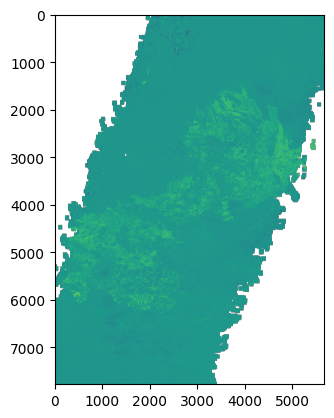

In [47]:
plt.imshow(10 * np.log10(hv_0/hv_1))